In [21]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [22]:
load_dotenv()
model = ChatOpenAI(model='gpt-4o-mini')

python-dotenv could not parse statement starting at line 1


In [23]:
#create schema 
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(
        description='Sentiment of the review'
    )

In [24]:
#diagonsis schema 
class DiagnosisSchema(BaseModel):

    issue_type: Literal[
        "UX",
        "Performance",
        "Bug",
        "Support",
        "Other"
    ]

    tone: Literal[
        "angry",
        "frustrated",
        "disappointed",
        "calm"
    ]

    urgency: Literal[
        "low",
        "medium",
        "high"
    ]

In [25]:
#create structural model
structured_model = model.with_structured_output(SentimentSchema)

structured_model2 = model.with_structured_output(DiagnosisSchema)

In [26]:
#test the sentimental model
prompt = 'What is the sentiment of the following review - The software too good'

structured_model.invoke(prompt).sentiment

OpenAIRateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}

In [27]:
#Define the Graph State
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [28]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'

    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [14]:
#conditional workflow actually happens.
def check_sentiment(state: ReviewState) -> Literal[
    "positive_response",
    "run_diagnosis"
]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [15]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:

    \n\n"{state['review']}"\n

    Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content

    return {'response': response}

In [ ]:
#negative diagonis
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:

    \n\n{state['review']}\n
    Return issue_type, tone, and urgency.
    """

    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [18]:
#negative response
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.

    The user had a '{diagnosis['issue_type']}' issue,
    sounded '{diagnosis['tone']}',
    and marked urgency as '{diagnosis['urgency']}'.

    Write an empathetic, helpful resolution message.
    """

    response = model.invoke(prompt).content

    return {'response': response}

In [19]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

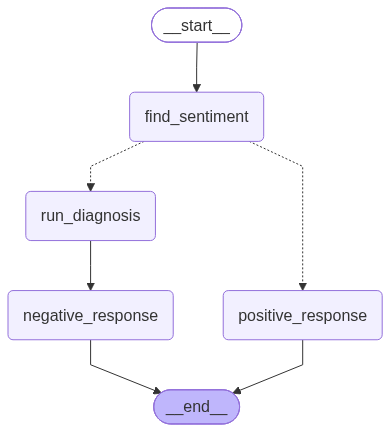

In [20]:
workflow

In [ ]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)